In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) * 0.1)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return torch.matmul(x, pruned_weights.t()) + self.bias

In [3]:
class PrunableNet(nn.Module):
    def __init__(self):
        super(PrunableNet, self).__init__()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x

    # Get all gates
    def get_all_gates(self):
        gates = []
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                gates.append(torch.sigmoid(module.gate_scores))
        return gates

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


In [5]:
def train_model(lambda_val, epochs=15):
    model = PrunableNet().to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            # Classification loss
            loss = criterion(outputs, labels)

            sparsity_loss = 0
            for g in model.get_all_gates():
                sparsity_loss += torch.mean(g)

            total_loss = loss + lambda_val * sparsity_loss

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

        print(f"Epoch {epoch+1}, Loss: {total_loss.item():.4f}")

    return model

In [6]:
def evaluate_model(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [7]:
def calculate_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0

    for g in model.get_all_gates():
        total += g.numel()
        pruned += torch.sum(g < threshold).item()

    return 100 * pruned / total

In [8]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [9]:
lambdas = [0.01, 0.1, 1.0]
results = []

best_model = None

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = train_model(lam)
    acc = evaluate_model(model)
    sparsity = calculate_sparsity(model)

    results.append((lam, acc, sparsity))

    if best_model is None or acc > best_model[1]:
        best_model = (model, acc)



Training with lambda = 0.01
Epoch 1, Loss: 1.8586
Epoch 2, Loss: 1.2955
Epoch 3, Loss: 1.2027
Epoch 4, Loss: 1.1067
Epoch 5, Loss: 1.1399
Epoch 6, Loss: 0.9646
Epoch 7, Loss: 0.9889
Epoch 8, Loss: 1.0313
Epoch 9, Loss: 0.9625
Epoch 10, Loss: 0.8118
Epoch 11, Loss: 0.7349
Epoch 12, Loss: 0.6589
Epoch 13, Loss: 0.5536
Epoch 14, Loss: 0.6966
Epoch 15, Loss: 0.5727

Training with lambda = 0.1
Epoch 1, Loss: 1.9564
Epoch 2, Loss: 1.4903
Epoch 3, Loss: 1.6630
Epoch 4, Loss: 1.6011
Epoch 5, Loss: 1.2584
Epoch 6, Loss: 1.2412
Epoch 7, Loss: 1.0400
Epoch 8, Loss: 1.1160
Epoch 9, Loss: 0.9623
Epoch 10, Loss: 1.0091
Epoch 11, Loss: 0.7697
Epoch 12, Loss: 0.9261
Epoch 13, Loss: 0.8438
Epoch 14, Loss: 0.6941
Epoch 15, Loss: 0.8523

Training with lambda = 1.0
Epoch 1, Loss: 3.1425
Epoch 2, Loss: 2.8304
Epoch 3, Loss: 2.3901
Epoch 4, Loss: 2.3376
Epoch 5, Loss: 2.2822
Epoch 6, Loss: 2.1065
Epoch 7, Loss: 1.9682
Epoch 8, Loss: 2.0420
Epoch 9, Loss: 1.7930
Epoch 10, Loss: 1.6974
Epoch 11, Loss: 1.6073

In [12]:
print("\nFinal Results:")
print("Lambda | Accuracy | Sparsity (%)")
for r in results:
    print(f"{r[0]} | {r[1]:.2f}% | {r[2]:.2f}%")




Final Results:
Lambda | Accuracy | Sparsity (%)
0.01 | 55.12% | 0.00%
0.1 | 54.42% | 0.00%
1.0 | 55.19% | 0.00%


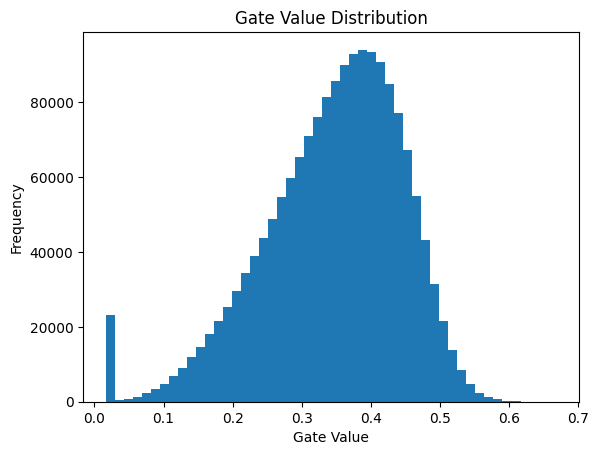

In [13]:
all_gates = []

for g in best_model[0].get_all_gates():
    all_gates.extend(g.detach().cpu().numpy().flatten())

plt.hist(all_gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()